In [ ]:
#Where we are summarizing land cover

In [ ]:
# pip install pandas

In [ ]:
# pip install geopandas


In [ ]:
# pip install matplotlib

In [ ]:
# pip install rasterio

In [ ]:
# pip install localtileserver ipyleaflet


In [ ]:
#Work on import and visualization

#For All of Baltimore City, determine the number of unique cell values for

#land cover raster, and 

#A land cover change raster (helps us work towards developing a function for summarizing these rasters in polygons)

#Make bar charts to communicate the amount of change in Baltimore city


In [1]:
import pandas as pd
import numpy as np


from localtileserver import TileClient


In [2]:
from localtileserver import get_leaflet_tile_layer
from ipyleaflet import Map
from ipyleaflet import Map, basemaps




In [9]:
#change rasters found at: https://www.sciencebase.gov/catalog/item/68011c83d4be0263cab101c8

change1to2 = "../landcover_spring2026_toobig/balt_24510_lulc-change_2013-2018_2024-Edition.tif"
# change1to3 = "../landcover_spring2026_toobig/balt_24510_lulc-change_2013-2021_2024-Edition.tif"                      
# change2to3 = "../landcover_spring2026_toobig/balt_24510_lulc-change_2018-2021_2024-Edition.tif"



In [3]:
client = TileClient('../landcover_spring2026_toobig/balt_24510_lulc-change_2013-2018_2024-Edition.tif')
client

Map(center=[39.297039, -76.618712], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

In [7]:
#subset for tree canopy related land cover change

df = pd.read_csv('lulcc_visualization_crosswalk-2024-edition.csv')
df2 = df[(df['lc_T1'] == "Tree Canopy") | (df['lc_T2'] == "Tree Canopy")]

In [11]:
#Count pixels

import rasterio

with rasterio.open(change1to2) as ras:
    ra = ras.read(1)
    nodata = ras.nodata

if nodata is not None:
    ra = ra[ra != nodata]


vals, counts = np.unique(ra, return_counts=True)

df_counts = pd.DataFrame({
    "Value": vals,
    "Counts": counts
})

#join counts with value lookup table

df_joined = df.merge(
    df_counts,
    on="Value",
    how="left"
)

#fill missing values absent from raster
df_joined["Counts"] = df_joined["Counts"].fillna(0).astype(int)

missing = set(vals) - set(df["Value"])
print("Missing entries:", missing)



Missing entries: set()


In [15]:
#check counts of pixels for each pixel value

df_joined




,Value,lulcc,lu_T1,lu_T2,lc_T1,lc_T2,general_T1,general_T2,macro_T1,macro_T2,Counts
0,1015,Tidal Waters to Bare Shore,Tidal Waters,Bare Shore,Water,Barren,Water,Natural Succession,Water,Natural,0
1,1020,Tidal Waters to Roads,Tidal Waters,Roads,Water,Impervious Roads,Water,Impervious Roads,Water,Developed,0
2,1021,Tidal Waters to Structures,Tidal Waters,Structures,Water,Impervious Structures,Water,Impervious Structures,Water,Developed,0
3,1022,Tidal Waters to Other Impervious,Tidal Waters,Other Impervious,Water,Other Impervious,Water,"Impervious, Other",Water,Developed,1554
4,1024,Tidal Waters to Tree Canopy Over Structures,Tidal Waters,Tree Canopy Over Structures,Water,Tree Canopy Over Impervious Structures,Water,Tree Canopy over Impervious,Water,Developed,0
...,...,...,...,...,...,...,...,...,...,...,...
1564,8681,Pasture and Hay Herbaceous to Cropland Herbaceous,Pasture and Hay,Cropland,Low Vegetation,Low Vegetation,Pasture and Hay,Cropland,Agricultural,Agricultural,0
1565,8682,Pasture and Hay Herbaceous to Orchards and Vin...,Pasture and Hay,Orchards and Vineyards,Low Vegetation,Barren,Pasture and Hay,Cropland,Agricultural,Agricultural,0
1566,8683,Pasture and Hay Herbaceous to Orchards and Vin...,Pasture and Hay,Orchards and Vineyards,Low Vegetation,Low Vegetation,Pasture and Hay,Cropland,Agricultural,Agricultural,0
1567,8684,Pasture and Hay Herbaceous to Orchards and Vin...,Pasture and Hay,Orchards and Vineyards,Low Vegetation,Shrubland,Pasture and Hay,Cropland,Agricultural,Agricultural,0


In [17]:
#group by macro_T1 and T2

df_changes = (
    df_joined
    .groupby(["macro_T1", "macro_T2"], as_index=False)
    .agg({"Value": "sum"})
)


df_changes["transition"] = (
    df_changes["macro_T1"] + " → " + df_changes["macro_T2"]
)

#remove counts of pixels that did not change

df_changes = df_changes[df_changes['macro_T1']!=df_changes['macro_T2']]


df_changes


,macro_T1,macro_T2,Value,transition
1,Agricultural,Developed,750282,Agricultural → Developed
2,Agricultural,Natural,367500,Agricultural → Natural
3,Agricultural,Water,190882,Agricultural → Water
4,Developed,Agricultural,225859,Developed → Agricultural
6,Developed,Natural,663446,Developed → Natural
7,Developed,Water,193235,Developed → Water
8,Natural,Agricultural,206066,Natural → Agricultural
9,Natural,Developed,1398711,Natural → Developed
11,Natural,Water,590612,Natural → Water
12,Water,Agricultural,26260,Water → Agricultural


<Figure size 1000x600 with 0 Axes>

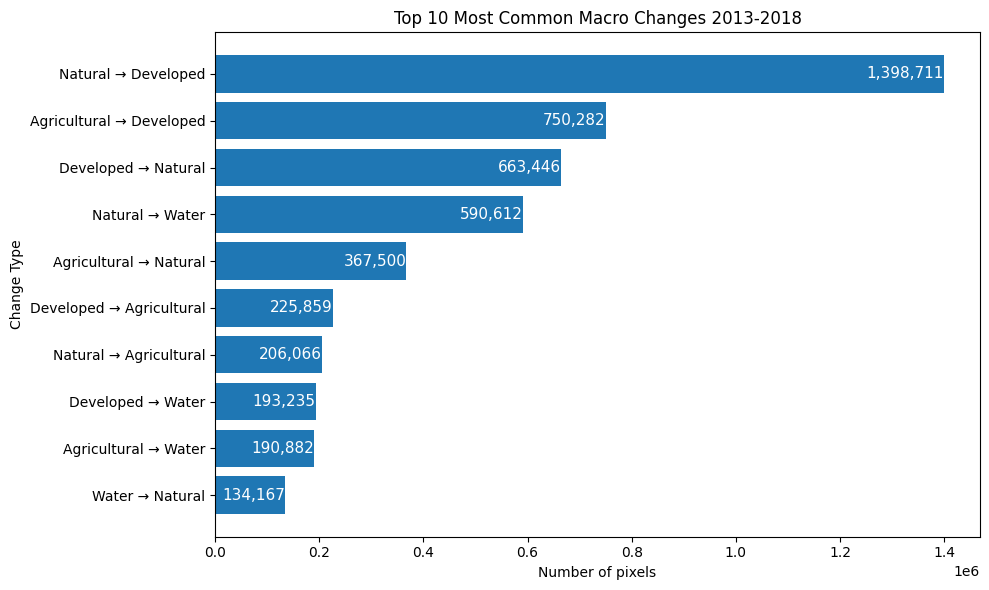

In [29]:
#find most common changes

top10 = (
    df_changes
    .sort_values("Value", ascending=False)
    .head(10)
)

#chart top macro changes

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top10["transition"],
    top10["Value"]
)

ax.invert_yaxis()
ax.set_xlabel("Number of pixels")
ax.set_ylabel("Change Type")
ax.set_title("Top 10 Most Common Macro Changes 2013-2018")

for i, value in enumerate(top10["Value"]):
    ax.text(
        value,
        i,
        f"{value:,}",
        va="center",
        ha="right",
        fontsize=11,
        color="white"
    )

plt.tight_layout()
plt.show()



In [19]:

#function that allows subsetting dataframe
#
# Duplicates are dropped

def change_dataframe_legend(
    m,
    raster_path,
    df,
    value_col="Value",
    t1_col="lc_T1",
    t2_col="lc_T2",
    cmap_name="tab20",
    opacity=0.8,
    legend_title="Land Cover Change",
    legend_position="bottomleft",
):
    """
    Adds a localtileserver tile layer AND a matching legend
    to an ipyleaflet Map.

    - One legend entry per unique (t1, t2) transition
    - All raster values representing the same transition
      are rendered with the same color
    """

    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from localtileserver import get_leaflet_tile_layer
    from ipyleaflet import WidgetControl
    import ipywidgets as widgets

    # ------------------------------------------------------------------
    # 1. Build transition-level legend table (deduplicated on t1 + t2)
    # ------------------------------------------------------------------
    legend_df = (
        df[[value_col, t1_col, t2_col]]
        .drop_duplicates(subset=[t1_col, t2_col])
        .sort_values([t1_col, t2_col])
        .reset_index(drop=True)
    )

    legend_df["label"] = (
        legend_df[t1_col].astype(str).str.title()
        + " → "
        + legend_df[t2_col].astype(str).str.title()
    )

    legend_df["transition_key"] = (
        legend_df[t1_col].astype(str) + "→" + legend_df[t2_col].astype(str)
    )

    # ------------------------------------------------------------------
    # 2. Assign ONE color per transition
    # ------------------------------------------------------------------
    base_cmap = plt.get_cmap(cmap_name)

    transition_colors = {
        key: mcolors.to_hex(base_cmap(i % base_cmap.N))
        for i, key in enumerate(legend_df["transition_key"])
    }

    legend_df["color"] = legend_df["transition_key"].map(transition_colors)

    # ------------------------------------------------------------------
    # 3. Map ALL raster values to their transition color
    # ------------------------------------------------------------------
    df = df.copy()
    df["transition_key"] = (
        df[t1_col].astype(str) + "→" + df[t2_col].astype(str)
    )

    value_to_color = {
        row[value_col]: transition_colors[row["transition_key"]]
        for _, row in df.iterrows()
    }

    all_values = sorted(value_to_color.keys())
    colors = [value_to_color[v] for v in all_values]

    cmap = mcolors.ListedColormap(colors)
    bounds = all_values + [all_values[-1] + 1]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # ------------------------------------------------------------------
    # 4. Add localtileserver layer
    # ------------------------------------------------------------------
    tile_layer = get_leaflet_tile_layer(
        raster_path,
        cmap=cmap,
        norm=norm,
        opacity=opacity,
    )
    m.add_layer(tile_layer)

    # ------------------------------------------------------------------
    # 5. Build legend HTML (one entry per transition)
    # ------------------------------------------------------------------
    legend_html = f"""
    <div style="
        background-color: white;
        border: 2px solid grey;
        padding: 8px;
        font-size: 11px;
        max-height: 200px;
        overflow-y: auto;
    ">
    <b>{legend_title}</b><br>
    """

    for _, row in legend_df.iterrows():
        legend_html += f"""
        <div style="margin-bottom:4px;">
            <span style="
                display:inline-block;
                width:14px;
                height:14px;
                background:{row['color']};
                margin-right:8px;
            "></span>
            {row['label']}
        </div>
        """

    legend_html += "</div>"

    legend_widget = widgets.HTML(value=legend_html)

    legend_control = WidgetControl(
        widget=legend_widget,
        position=legend_position,
    )

    m.add_control(legend_control)

    return tile_layer


In [6]:


#make map of subsetted dataframe

m = Map(center=(39.3, -76.6), zoom=11, basemap=basemaps.Esri.WorldImagery)


m.layers[0].style = {
    "filter": "grayscale(90%) brightness(1.3) contrast(1.1)"
}

change_dataframe_legend(
    m,
    raster_path="../landcover_spring2026_toobig/balt_24510_lulc-change_2013-2018_2024-Edition.tif",
    df=df2,
    legend_title="Forest Change 2013-2018",
    opacity=0.9
)


m

/Users/moski/Documents/landcover/lc-env/lib/python3.13/site-packages/localtileserver/widgets.py:91: UserWarning: The `cmap` keyword argument is deprecated. Please use `colormap` instead.
  warnings.warn(


Map(center=[39.3, -76.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [55]:
from ipyleaflet import Map

m = Map(center=(39.3, -76.6), zoom=11, basemap=basemaps.Esri.WorldImagery)


m.layers[0].style = {
    "filter": "grayscale(90%) brightness(1.3) contrast(1.1)"
}

change_dataframe_legend(
    m,
    raster_path="../landcover_spring2026_toobig/balt_24510_lulc-change_2018-2021_2024-Edition.tif",
    #raster_path="../landcover_spring2026_toobig/balt_24510_lulc-change_2013-2018_2024-Edition.tif",
    df=df2,
    legend_title="Land Cover Change 2013-2018",
    value_col="Value",
    t1_col="macro_T1",
    t2_col="macro_T2",
    opacity=0.4
)

m

/Users/moski/Documents/landcover/lc-env/lib/python3.13/site-packages/localtileserver/widgets.py:91: UserWarning: The `cmap` keyword argument is deprecated. Please use `colormap` instead.
  warnings.warn(


Map(center=[39.3, -76.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [ ]:
#group by
#




In [ ]:
from ipyleaflet import Map

m = Map(center=(39.3, -76.6), zoom=11, basemap=basemaps.Esri.WorldImagery)


m.layers[0].style = {
    "filter": "grayscale(90%) brightness(1.3) contrast(1.1)"
}

change_dataframe_legend(
    m,
    raster_path="../landcover_spring2026_toobig/balt_24510_lulc-change_2013-2018_2024-Edition.tif",
    df=df2,
    legend_title="Land Cover Change 2013-2018",
    value_col="Value",
    t1_col="macro_T1",
    t2_col="macro_T2"
)

m

In [ ]:
#some land cover change is mapped
#next map land cover again with interactive map



In [11]:
m = Map()
m.add(get_leaflet_tile_layer(client, colormap='gist_earth', vmin=-500, vmax=5000))
m

Map(center=[0.0, 0.0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_t…

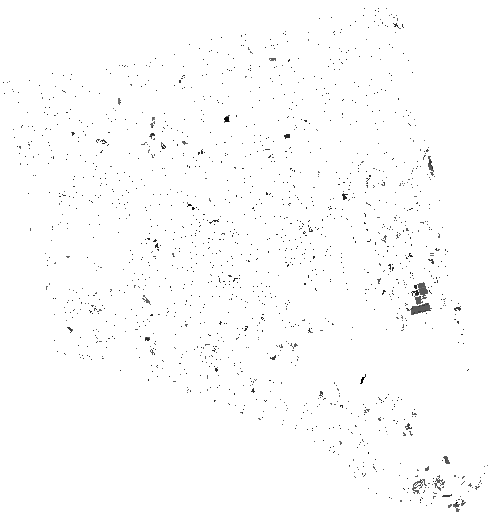

In [7]:
client.thumbnail()



**Old Code Below**


In [1]:
import pandas as pd
import geopandas as gpd
import rasterio as ras
import matplotlib.pyplot as plt
from rasterio.plot import show
from shapely.geometry import Point, Polygon, LineString


In [2]:
#change rasters found at: https://www.sciencebase.gov/catalog/item/68011c83d4be0263cab101c8

change1to2 = "../landcover_spring2026_toobig/balt_24510_lulc-change_2013-2018_2024-Edition.tif"
# change1to3 = "../landcover_spring2026_toobig/balt_24510_lulc-change_2013-2021_2024-Edition.tif"                      
# change2to3 = "../landcover_spring2026_toobig/balt_24510_lulc-change_2018-2021_2024-Edition.tif"



In [ ]:
#approach doesn't work, the kernel crashes

rast = ras.open(change1to2)
show(rast, cmap='viridis')
plt.show()

rast.close()

In [8]:
#read pixels in the raster

band1 = ras.open(change1to2).read(1)
band1

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(19548, 18877), dtype=uint16)

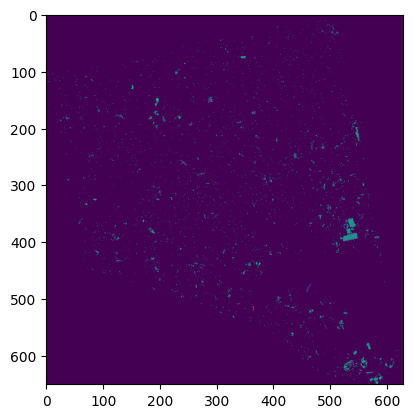

In [3]:
#reduce raster resolution with decimation to avoid kernel crashing
#visualize raster reading every 30th pixel

with ras.open(change1to2) as raster:
    decima = raster.read(1, out_shape=(1, int(raster.height / 30), int(raster.width / 30)))
    show(decima)
    raster.close()




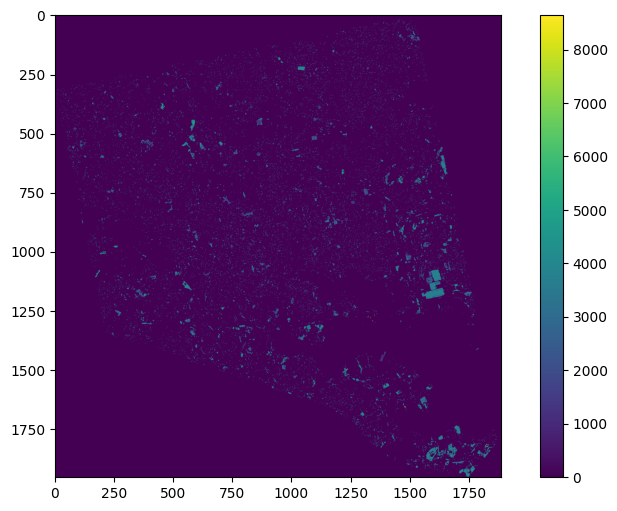

In [4]:
#reducing resolution to visualize raster without crashing
#uses 100x less pixels

from rasterio.enums import Resampling

with ras.open(change1to2) as rast:
    scale = 10
    data = rast.read(1,out_shape=(rast.height // scale,rast.width // scale),resampling=Resampling.average)
    
fig, ax = plt.subplots(figsize=(10, 6))
fig.colorbar(ax.imshow(data, cmap="viridis"), ax=ax)
plt.show()
rast.close()



In [ ]:

#(OLD FUNCTION) (use change_dataframe_legend instead)

#function to place legend based on raster pixel values with a given pixel value CSV:

def change_csv_legend(
    m,
    raster_path,
    csv_path,
    value_col="value",
    t1_col="t1",
    t2_col="t2",
    cmap_name="tab20",
    opacity=0.8,
    legend_title="Land Cover Change",
    legend_position="bottomleft",
):
    """
    Adds a localtileserver tile layer AND a matching legend
    to an ipyleaflet Map.
    """

    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from localtileserver import get_leaflet_tile_layer
    from ipyleaflet import WidgetControl
    import ipywidgets as widgets

    # --- Read & prepare CSV ---
    df = pd.read_csv(csv_path)

    legend_df = (
        df[[value_col, t1_col, t2_col]]
        .drop_duplicates()
        .sort_values(value_col)
        .reset_index(drop=True)
    )

    legend_df["label"] = (
        legend_df[t1_col].str.title()
        + " → "
        + legend_df[t2_col].str.title()
    )

    values = legend_df[value_col].tolist()
    n = len(values)

    # --- Build categorical colormap ---
    base_cmap = plt.get_cmap(cmap_name)
    colors = [
        mcolors.to_hex(base_cmap(i % base_cmap.N))
        for i in range(n)
    ]

    cmap = mcolors.ListedColormap(colors)

    bounds = values + [values[-1] + 1]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # --- Add tile layer ---
    tile_layer = get_leaflet_tile_layer(
        raster_path,
        cmap=cmap,
        norm=norm,
        opacity=opacity,
    )
    m.add_layer(tile_layer)

    # --- Build legend HTML ---
    legend_html = f"""
    <div style="
        background-color: white;
        border: 1.4px solid grey;
        padding: 8px;
        font-size: 12px;
        max-height: 200px;
        overflow-y: auto;
    ">
    <b>{legend_title}</b><br>
    """

    for _, row in legend_df.iterrows():
        color = colors[row.name]
        legend_html += f"""
        <div style="margin-bottom:4px;">
            <span style="
                display:inline-block;
                width:14px;
                height:14px;
                background:{color};
                margin-right:8px;
            "></span>
            {row['label']}
        </div>
        """

    legend_html += "</div>"

    # --- Add legend as widget ---
    legend_widget = widgets.HTML(value=legend_html)

    legend_control = WidgetControl(
        widget=legend_widget,
        position=legend_position,
    )

    m.add_control(legend_control)

    return tile_layer


In [ ]:
from ipyleaflet import Map

m = Map(center=(39.3, -76.6), zoom=11)

change_csv_legend(
    m,
    raster_path="../landcover_spring2026_toobig/balt_24510_lulc-change_2013-2018_2024-Edition.tif",
    csv_path="lulcc_visualization_crosswalk-2024-edition.csv",
    legend_title="Land Cover Change 2013-2018",
    value_col="Value",
    t1_col="macro_T1",
    t2_col="macro_T2"
)

m